In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from multiprocessing import Pool
from joblib import Parallel, delayed
from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS
from itertools import product
import gc
from concurrent.futures import ProcessPoolExecutor

COLOR_LIST = list(COLORS.values())

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
USE_CACHED_RESULTS = False
DPI = 300

Raw data not used in the paper is not included in the review version due to size.
Navigate to "Load Data for Figure 3 to reproduce"

# Ensembling

In [3]:
data_bm = pd.read_csv('/home/kocher/RA-AML/analysis/data/base_with_inference/base_model_pools.csv', index_col=0)
data_ens = pd.read_csv('/home/kocher/RA-AML/analysis/data/base_with_inference/base_ensemble_pools.csv', index_col=0)

data_ens = data_ens[data_ens["filter"].isin(["nd_50_silo", "none"])]
data_ens = data_ens[data_ens["frequency"] == "boost"]
data_bm = data_bm[data_bm["frequency"] == "boost"]
data_bm = data_bm[data_bm["time"] < 0]

gc.collect()


0

In [ ]:
print(data_bm.head(n=3))
print(data_ens.head(n=3))

        RMSE  inference_time  energy_consumption  ensemble_size  avg_gap  task_id  seed bmg_method  pool_index   RMSE_ens  inference_time_ens  energy_consumption_ens       inference_times frequency  time  Log Loss  Log Loss_ens  1 - ROC AUC  1 - ROC AUC_ens
0  26.185523        0.009884            0.061829            1.0      0.0   167210     1    so-smac           1  24.759347            0.010264                0.061856  [0.0098835700191557]     boost    -1       NaN           NaN          NaN              NaN
1  23.504768        0.016125            0.125443            1.0      0.0   167210     1    so-smac           1  21.973898            0.013963                0.104007  [0.0161247802898287]     boost    -1       NaN           NaN          NaN              NaN
2  22.149986        0.039696            0.290420            1.0      0.0   167210     1    so-smac           1  21.769879            0.031710                0.231049  [0.0396956140175461]     boost    -1       NaN           Na

In [5]:
with open("/home/kocher/RA-AML/analysis/data/classification_meta.yaml", "r") as f:
    meta = yaml.safe_load(f)
with open("/home/kocher/RA-AML/analysis/data/regression_meta.yaml", "r") as f:
    meta.update(yaml.safe_load(f))
TASK_IDS = list(meta.keys())
SEEDS = [1, 2, 3, 4, 5]

In [6]:
BMG_METHODS_DICT = {
    "so-smac" : "SO-SMAC",

}
BMG_METHODS = list(BMG_METHODS_DICT.keys())

ENSEMBLING_METHODS_DICT = {
    "ges" : "GES",
}
ENSEMBLING_METHODS = list(ENSEMBLING_METHODS_DICT.keys())

ALLOTMENT_STRATEGIES_DICT = {
    "full" : "FFS",
    "nsga2" : "NSGA-II-FS",
    "min": "Min-FS",
}
ALLOTMENT_STRATEGIES = list(ALLOTMENT_STRATEGIES_DICT.keys())

SCHEDULING_STRATEGIES_DICT = {
    "lpt" : "LPT",
    "hws" : "HWL",
    "htcs" : "HCC",
}
SCHEDULING_STRATEGIES = list(SCHEDULING_STRATEGIES_DICT.keys())

In [7]:
if not os.path.exists("/home/kocher/RA-AML/analysis/data/processed_data"):
    os.makedirs("/home/kocher/RA-AML/analysis/data/processed_data")

if os.path.exists("/home/kocher/RA-AML/analysis/data/processed_data/min_max.yaml"):
    with open("/home/kocher/RA-AML/analysis/data/processed_data/min_max.yaml", "r") as f:
        min_max_values = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    min_max_values = compute_min_max(all_df)
    with open("/home/kocher/RA-AML/analysis/data/processed_data/min_max.yaml", "w") as f:
        yaml.dump(min_max_values, f)
    del all_df
assert len(min_max_values) == 104

In [8]:
if os.path.exists("/home/kocher/RA-AML/analysis/data/processed_data/extremes.yaml"):
    with open("/home/kocher/RA-AML/analysis/data/processed_data/extremes.yaml", "r") as f:
        extremes = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    extremes = compute_extremes(min_max_values, all_df)
    with open("/home/kocher/RA-AML/analysis/data/processed_data/extremes.yaml", "w") as f:
        yaml.dump(extremes, f)
    del all_df
assert len(extremes) == 104

In [9]:
data_bm_grouped = data_bm.groupby(["task_id", "seed", "bmg_method"])
data_ens_grouped = data_ens.groupby(["task_id", "seed", "bmg_method", "es_method"])

In [10]:
def min_distance(vectors, paret_front, ignore_self=False):
    diff = vectors[:, None, :] - paret_front[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    if ignore_self:
        np.fill_diagonal(dist, np.inf)
    return np.min(dist, axis=1)

def compute_spread(extent, sum_deviations, denom):
    assert np.isfinite(extent) and np.isfinite(sum_deviations) and np.isfinite(denom), "Values must be finite"
    return (extent + sum_deviations) / (extent + denom)

def compute_extent(pareto_front, cols, extremes):
    extremes_array = np.array([[e[col] for col in cols] for e in extremes.values()])
    sum_extremes = np.sum(min_distance(extremes_array, pareto_front))
    return sum_extremes

def compute_uniformity_components(pareto_front, cols):
    assert len(pareto_front) > 0, "Pareto front is empty"
    if len(pareto_front) == 1:
        return 1.0, 1.0 

    distances = min_distance(pareto_front, pareto_front, ignore_self=True)
    assert not np.any(np.isinf(distances)), "Distances contain infinity"
        
    d_mean = np.mean(distances)
    assert np.abs(d_mean) >= 1e-14, "Mean distance is too small"

    sum_deviations = np.sum(np.abs(distances - d_mean))
    return sum_deviations, len(pareto_front) * d_mean

def compute_uniformity(sum_deviations, denom):
    return sum_deviations / denom


def filter_duplicates(arr):
    unique = []
    for row in arr:
        if not any(np.abs(row - u).sum() < 1e-6 for u in unique):
            unique.append(row)
    return np.array(unique)

def compute_hvs(data, log_mask, min_arr, max_arr):
    ind = HV(ref_point=[1] * 3)
    data_norm = (data - min_arr) / (max_arr - min_arr)
    hv = ind(data_norm)
    
    data_log_scaled = data.copy()
    data_log_scaled[:, log_mask] = np.log10(data_log_scaled[:, log_mask] + 1e-10)
    min_arr_log = min_arr.copy()
    min_arr_log[log_mask] = np.log10(min_arr_log[log_mask] + 1e-10)
    max_arr_log = max_arr.copy()
    max_arr_log[log_mask] = np.log10(max_arr_log[log_mask] + 1e-10)
    data_log_norm = (data_log_scaled - min_arr_log) / (max_arr_log - min_arr_log)
    hv_log = ind(data_log_norm)
    return hv, hv_log, data_norm

In [11]:
def compute_metrics_for_data(data, min_arr, max_arr, cols, extremes, task_id, log_mask):
    data_orig = data.copy()
    
    hv, hv_log, data = compute_hvs(data, log_mask, min_arr, max_arr)
    
    data_pareto_mask = get_pareto_front(data)
    data_pareto = data[data_pareto_mask]
    data_pareto = filter_duplicates(data_pareto)
    
    data_extent = compute_extent(data_pareto, cols, extremes[task_id])
    data_sum_deviations, data_denom = compute_uniformity_components(data_pareto, cols)
    data_spread = compute_spread(data_extent, data_sum_deviations, data_denom)
    data_uniformity = compute_uniformity(data_sum_deviations, data_denom)
    
    data_n = len(data)
    data_onvg = len(data_pareto)
    
    return hv, hv_log, data_spread, data_onvg, data_n, data_uniformity, data_extent, data_orig

# Parallelization

In [12]:
data_parallel = pd.read_csv('/home/kocher/RA-AML/analysis/data/extended_allotment_50_iterations_silo/parallel_alloted_eps.csv', index_col=0)
data_parallel_grouped = data_parallel.groupby(["task_id", "seed", "bmg_method", "ensembling_method", "allotment_method","n_cores","scheduler"])

In [13]:
data_parallel_grouped.get_group((TASK_IDS[0], SEEDS[0], BMG_METHODS[0], ENSEMBLING_METHODS[0], ALLOTMENT_STRATEGIES[0], 16, SCHEDULING_STRATEGIES[0]))

,RMSE,inference_time,energy_consumption,ensemble_size,avg_gap,old_ensemble_index,task_id,seed,bmg_method,pool_index,n_cores,scheduler,allotment_method,ensembling_method,Log Loss,1 - ROC AUC
Unnamed: 0,,,,,,,,,,,,,,,,
0,NaN,0.028276,1.643129,1.0,0.0,0.0,2073,1,so-smac,111495,16,lpt,full,ges,1.012168,NaN
1,NaN,0.042278,1.866455,2.0,0.0,1.0,2073,1,so-smac,111495,16,lpt,full,ges,1.038518,NaN
2,NaN,0.070522,3.522630,3.0,0.0,2.0,2073,1,so-smac,111495,16,lpt,full,ges,1.024037,NaN
3,NaN,0.076757,3.703769,4.0,0.0,3.0,2073,1,so-smac,111495,16,lpt,full,ges,1.004267,NaN
4,NaN,0.105015,5.358127,5.0,0.0,4.0,2073,1,so-smac,111495,16,lpt,full,ges,1.000103,NaN
5,NaN,0.105015,5.358127,5.0,0.0,5.0,2073,1,so-smac,111495,16,lpt,full,ges,1.009175,NaN
6,NaN,0.105015,5.358127,5.0,0.0,6.0,2073,1,so-smac,111495,16,lpt,full,ges,1.006102,NaN
7,NaN,0.134978,7.056077,6.0,0.0,7.0,2073,1,so-smac,111495,16,lpt,full,ges,1.004414,NaN
8,NaN,0.148718,7.272950,7.0,0.0,8.0,2073,1,so-smac,111495,16,lpt,full,ges,1.010904,NaN


In [14]:
data_parallel["allotment_method"].unique()

array(['full', 'min', 'nsga2'], dtype=object)

In [15]:
def process_job(task_id, seed, bmg_method):
    results = []
    df_comp_data = []
    
    try:
        bm_group = data_bm_grouped.get_group((task_id, seed, bmg_method))
    except KeyError:
        for ensembling_method in ENSEMBLING_METHODS:
            for n_cores in [2,4,8]:
                for allotment_method in ALLOTMENT_STRATEGIES:
                    for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                        results.append([
                            task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                            [*([0]*8), *([np.nan]*4), *([0]*8),  *([np.nan]*4), *([np.nan]*4), *([0]*4)]
                        ])
        return results, []
    
    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~bm_group[col].isna()).sum() > 0]
    log_mask = [1,2]
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    assert bm_group["pool_index"].nunique() == 1, "Multiple pools found"

    min, max = min_max_values[task_id]
    min_arr, max_arr = np.array([min[col] for col in cols]), np.array([max[col] for col in cols])
    
    bm_data = bm_group[cols].values
    bm_data_pareto_ens = get_pareto_front(bm_group[cols_ens].values)
    bm_data_pareto_ens_indices = np.where(bm_data_pareto_ens)[0]
    bm_data = bm_data[bm_data_pareto_ens]
    
    bm_hv, bm_hv_log, bm_spread, bm_onvg, bm_n, bm_uniformity, bm_extent, bm_data_orig = compute_metrics_for_data(
        bm_data, min_arr, max_arr, cols, extremes, task_id, log_mask
    )
    bm_avg_gap = np.mean(bm_group["avg_gap"])
    
    
    for ensembling_method in ENSEMBLING_METHODS:
        try:
            ens_group = data_ens_grouped.get_group((task_id, seed, bmg_method, ensembling_method))
        except KeyError:
            for n_cores in [2,4,8]:
                for allotment_method in ALLOTMENT_STRATEGIES:
                    for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                        results.append([
                            task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                            [
                                bm_hv, bm_hv, bm_hv, bm_hv,
                                bm_hv_log, bm_hv_log, bm_hv_log, bm_hv_log,
                                bm_spread, bm_spread, bm_spread, bm_spread,
                                bm_onvg, bm_onvg, bm_onvg, bm_onvg,
                                bm_n, bm_n, bm_n, bm_n,
                                bm_uniformity, bm_uniformity, bm_uniformity, bm_uniformity,
                                bm_extent, bm_extent, bm_extent, bm_extent,
                                bm_avg_gap, bm_avg_gap, bm_avg_gap, bm_avg_gap
                            ]                     
                        ])
            continue
        
        data_ens = ens_group[cols].values
        data_ens_pareto_ens = get_pareto_front(ens_group[cols_ens].values)
        data_ens_pareto_ens_indicies = np.where(data_ens_pareto_ens)[0]
        data_ens = data_ens[data_ens_pareto_ens]
        
        data_bm_ens = np.vstack([bm_data_orig, data_ens])
        bm_ens_hv, bm_ens_hv_log, bm_ens_spread, bm_ens_onvg, bm_ens_n, bm_ens_uniformity, bm_ens_extent, _ = compute_metrics_for_data(
            data_bm_ens, min_arr, max_arr, cols, extremes, task_id, log_mask
        )
        bm_ens_avg_gap = np.mean(ens_group["avg_gap"])
            
        for n_cores in [2,4,8,16,32,64]:
            for allotment_method in ALLOTMENT_STRATEGIES:
                for scheduler in ["lpt", "hws", "htcs"] if allotment_method == "nsga2" else ["lpt"]:
                    bm_allotment_group = data_parallel_grouped.get_group((task_id, seed, bmg_method, "base_model_pool", allotment_method, n_cores, scheduler))  
                    bm_allotment_group_filtered = bm_allotment_group[bm_allotment_group["old_ensemble_index"].astype(int).isin(bm_data_pareto_ens_indices)]
                    bm_a_hv, bm_a_hv_log, bm_a_spread, bm_a_onvg, bm_a_n, bm_a_uniformity, bm_a_extent, bm_a_data_orig = compute_metrics_for_data(
                        bm_allotment_group_filtered[cols].values, min_arr, max_arr, cols, extremes, task_id, log_mask
                    )
                    bm_a_avg_gap = np.mean(bm_allotment_group["avg_gap"])
                    
                    data_ens_allotment_group = data_parallel_grouped.get_group((task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler))
                    data_ens_allotment_group_filtered = data_ens_allotment_group[
                        data_ens_allotment_group["old_ensemble_index"].astype(int).isin(data_ens_pareto_ens_indicies)
                    ]

                    data_bm_ens_a = np.vstack([bm_a_data_orig, data_ens_allotment_group_filtered[cols].values])
                    bm_ens_a_hv, bm_ens_a_hv_log, bm_ens_a_spread, bm_ens_a_onvg, bm_ens_a_n, bm_ens_a_uniformity, bm_ens_a_extent, _ = compute_metrics_for_data(
                        data_bm_ens_a, min_arr, max_arr, cols, extremes, task_id, log_mask
                    )
                    bm_ens_a_avg_gap = np.mean(data_ens_allotment_group_filtered[data_ens_allotment_group_filtered['ensemble_size'] == data_ens_allotment_group_filtered['ensemble_size'].max()]["avg_gap"])
                    
                    if scheduler == "lpt":
                        df_comp_data.append({
                            "task_id": task_id,
                            "seed": seed,
                            "bmg_method": bmg_method,
                            "ensembling_method": ensembling_method,
                            "allotment_method": allotment_method,
                            "n_cores": n_cores,
                            "data_ens": data_ens_allotment_group_filtered,
                            "data_bm": bm_allotment_group_filtered,
                            "data_ens_final_ensembles": data_ens_allotment_group_filtered[data_ens_allotment_group_filtered['ensemble_size'] == data_ens_allotment_group_filtered['ensemble_size'].max()],
                        })
                    
                    results.append([
                        task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler,
                        [
                            bm_hv, bm_ens_hv, bm_a_hv, bm_ens_a_hv,
                            bm_hv_log, bm_ens_hv_log, bm_a_hv_log, bm_ens_a_hv_log,
                            bm_spread, bm_ens_spread, bm_a_spread, bm_ens_a_spread,
                            bm_onvg, bm_ens_onvg, bm_a_onvg, bm_ens_a_onvg,
                            bm_n, bm_ens_n, bm_a_n, bm_ens_a_n,
                            bm_uniformity, bm_ens_uniformity, bm_a_uniformity, bm_ens_a_uniformity,
                            bm_extent, bm_ens_extent, bm_a_extent, bm_ens_a_extent,
                            bm_avg_gap, bm_ens_avg_gap, bm_a_avg_gap, bm_ens_a_avg_gap
                        ]
                    ])
            
            
    return results, df_comp_data

In [17]:
METRICS_ORDER = [
    "hv_bmp", "hv_bmp+ens", "hv_bmp_allotment", "hv_bmp+ens_allotment",
    "hv_log_bmp", "hv_log_bmp+ens", "hv_log_bmp_allotment", "hv_log_bmp+ens_allotment",
    "spread_bmp", "spread_bmp+ens", "spread_bmp_allotment", "spread_bmp+ens_allotment",
    "onvg_bmp", "onvg_bmp+ens", "onvg_bmp_allotment", "onvg_bmp+ens_allotment",
    "n_bmp", "n_bmp+ens", "n_bmp_allotment", "n_bmp+ens_allotment",
    "uniformity_bmp", "uniformity_bmp+ens", "uniformity_bmp_allotment", "uniformity_bmp+ens_allotment",
    "extent_bmp", "extent_bmp+ens", "extent_bmp_allotment", "extent_bmp+ens_allotment",
    "avg_gap_bmp", "avg_gap_bmp+ens", "avg_gap_bmp_allotment", "avg_gap_bmp+ens_allotment",
]

N_CORES_LIST = [2,4,8,16,32,64]
N_CORES_LIST_SUBSET = [2,4,8]
TASK_IDS.remove(359970)
results_parallel_full = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(N_CORES_LIST), len(METRICS_ORDER))) 
results_parallel_nsga2 = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(SCHEDULING_STRATEGIES), len(N_CORES_LIST), len(METRICS_ORDER)))
results_parallel_min = np.zeros((len(TASK_IDS), len(SEEDS), len(BMG_METHODS), len(ENSEMBLING_METHODS), len(SCHEDULING_STRATEGIES), len(N_CORES_LIST), len(METRICS_ORDER)))
def process_wrapper(args):
    task_id, seed, bmg_method = args
    res = process_job(task_id, seed, bmg_method)
    return res

if os.path.exists("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_full.npy") and USE_CACHED_RESULTS:
    results_parallel_full = np.load("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_full.npy")
    results_parallel_nsga2 = np.load("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_nsga2.npy")
    results_parallel_min = np.load("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_min.npy")
    raise NotImplementedError("Comparison data caching not implemented")
else:
    jobs = list(product(TASK_IDS, SEEDS, BMG_METHODS))
    data_comp = []
    
    with ProcessPoolExecutor(max_workers=8) as executor:
        for results_list, comp_data_single in tqdm.tqdm(
            executor.map(process_wrapper, jobs),
            total=len(jobs)
        ):
            for result in results_list:
                task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler, metrics = result
                t_idx = TASK_IDS.index(task_id)
                s_idx = SEEDS.index(seed)
                bmg_idx = BMG_METHODS.index(bmg_method)
                ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
                allot_idx = ALLOTMENT_STRATEGIES.index(allotment_method)
                n_cores_idx = N_CORES_LIST.index(n_cores)
                if allotment_method == "full":
                    results_parallel_full[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
                elif allotment_method == "nsga2":
                    sched_idx = SCHEDULING_STRATEGIES.index(scheduler)
                    results_parallel_nsga2[t_idx, s_idx, bmg_idx, ens_idx, sched_idx, n_cores_idx, :] = np.array(metrics)
                else:
                    sched_idx = SCHEDULING_STRATEGIES.index(scheduler)
                    results_parallel_min[t_idx, s_idx, bmg_idx, ens_idx, sched_idx, n_cores_idx, :] = np.array(metrics)   

            
            data_comp.extend(comp_data_single)
                
                            
    # for job in tqdm.tqdm(jobs):
    #     results_list, comp_results_list = process_wrapper(job)
    #     for result in results_list:
    #         task_id, seed, bmg_method, ensembling_method, allotment_method, n_cores, scheduler, metrics = result
    #         t_idx = TASK_IDS.index(task_id)
    #         s_idx = SEEDS.index(seed)
    #         bmg_idx = BMG_METHODS.index(bmg_method)
    #         ens_idx = ENSEMBLING_METHODS.index(ensembling_method)
    #         n_cores_idx = N_CORES_LIST.index(n_cores)
    #         if allotment_method == "full":
    #             results_parallel_full[t_idx, s_idx, bmg_idx, ens_idx, n_cores_idx, :] = np.array(metrics)
    #         else:
    #             sched_idx = SCHEDULING_STRATEGIES.index(scheduler)
    #             results_parallel_nsga2[t_idx, s_idx, bmg_idx, ens_idx, sched_idx, n_cores_idx, :] = np.array(metrics)
                
    #     for comp_result in comp_results_list:
    #         full_comp_results.append(comp_result)
            
    
    np.save("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_full.npy", results_parallel_full)
    np.save("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_nsga2.npy", results_parallel_nsga2)
    np.save("/home/kocher/RA-AML/analysis/data/processed_data/parallel_allot_processed_min.npy", results_parallel_min)

100%|██████████| 510/510 [00:04<00:00, 105.76it/s]


In [18]:
data_comp[0]["data_ens"]

,RMSE,inference_time,energy_consumption,ensemble_size,avg_gap,old_ensemble_index,task_id,seed,bmg_method,pool_index,n_cores,scheduler,allotment_method,ensembling_method,Log Loss,1 - ROC AUC
Unnamed: 0,,,,,,,,,,,,,,,,
0,NaN,14.655160,249.920257,1.0,0.0,0.0,3945,1,so-smac,115159,2,lpt,full,ges,NaN,0.263949
1,NaN,15.068965,253.408981,2.0,0.0,1.0,3945,1,so-smac,115159,2,lpt,full,ges,NaN,0.262463
6,NaN,29.933387,502.490004,4.0,0.0,6.0,3945,1,so-smac,115159,2,lpt,full,ges,NaN,0.265027
15,NaN,30.610036,507.686110,6.0,0.0,15.0,3945,1,so-smac,115159,2,lpt,full,ges,NaN,0.264671
42,NaN,31.969671,518.077942,10.0,0.0,42.0,3945,1,so-smac,115159,2,lpt,full,ges,NaN,0.264518


### Average Gap Comparison (Scheduling)

In [19]:
def compare_scheduler(relative=False, save_path=None):
    metric_index = METRICS_ORDER.index("avg_gap_bmp+ens_allotment")
    
    gap_vals = results_parallel_nsga2[..., metric_index]  # Shape: 104,5,6,6,6,3,3
    gap_vals = gap_vals.reshape((-1, len(SCHEDULING_STRATEGIES), len(N_CORES_LIST)))  # Shape: X, 3, 3
    
    data = []
    
    for n_cores in N_CORES_LIST_SUBSET:
        n_cores_idx = N_CORES_LIST_SUBSET.index(n_cores)
        vals = gap_vals[:, :, n_cores_idx]
        for scheduler in SCHEDULING_STRATEGIES:
            scheduler_idx = SCHEDULING_STRATEGIES.index(scheduler)
            for val in vals[:, scheduler_idx]:
                data.append({
                    "Scheduler": SCHEDULING_STRATEGIES_DICT[scheduler],
                    "Number of Cores": n_cores,
                    "Avg Gap": val
                }) 
    df = pd.DataFrame(data)
    
    
    if not relative:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
        df["Avg Gap"] = df["Avg Gap"] * 100
        sns.boxplot(
            data=df,
            x="Number of Cores",
            y="Avg Gap",
            hue="Scheduler",
            palette=COLOR_LIST[:len(SCHEDULING_STRATEGIES)],
            ax=ax,
            showfliers=False
        )
        ax.set_xlabel("Number of Cores")
        ax.set_ylabel("Average Idle Time per Core [%]")
    else:
        fig, ax = plt.subplots(figsize=(6, 4), dpi=DPI)
        gap_vals_norm = gap_vals / (gap_vals.max(axis=1, keepdims=True) + 1e-12)
        gap_vals_norm_mean = gap_vals_norm.mean(axis=0)  # Shape: 3,4
        gap_vals_norm_std = gap_vals_norm.std(axis=0)    # Shape: 3,4
        print(gap_vals_norm_mean.shape, gap_vals_norm.shape)
        
        x = np.arange(len(N_CORES_LIST))
        for scheduler in SCHEDULING_STRATEGIES:
            scheduler_idx = SCHEDULING_STRATEGIES.index(scheduler)
            means = gap_vals_norm_mean[scheduler_idx]
            stds = gap_vals_norm_std[scheduler_idx]
            ax.plot(x, means, label=SCHEDULING_STRATEGIES_DICT[scheduler], color=COLOR_LIST[scheduler_idx])
            ax.fill_between(x, np.clip(means - stds, 0, 1), np.clip(means + stds, 0, 1), color=COLOR_LIST[scheduler_idx], alpha=0.1)
        ax.set_xticks(x)
        ax.set_xticklabels(N_CORES_LIST)
        ax.set_xlabel("Number of Cores")
        ax.set_ylabel("Max-Normalised Average Gap")
    ax.legend(title="Scheduling Strategy")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
    else:
        plt.show()
        
    

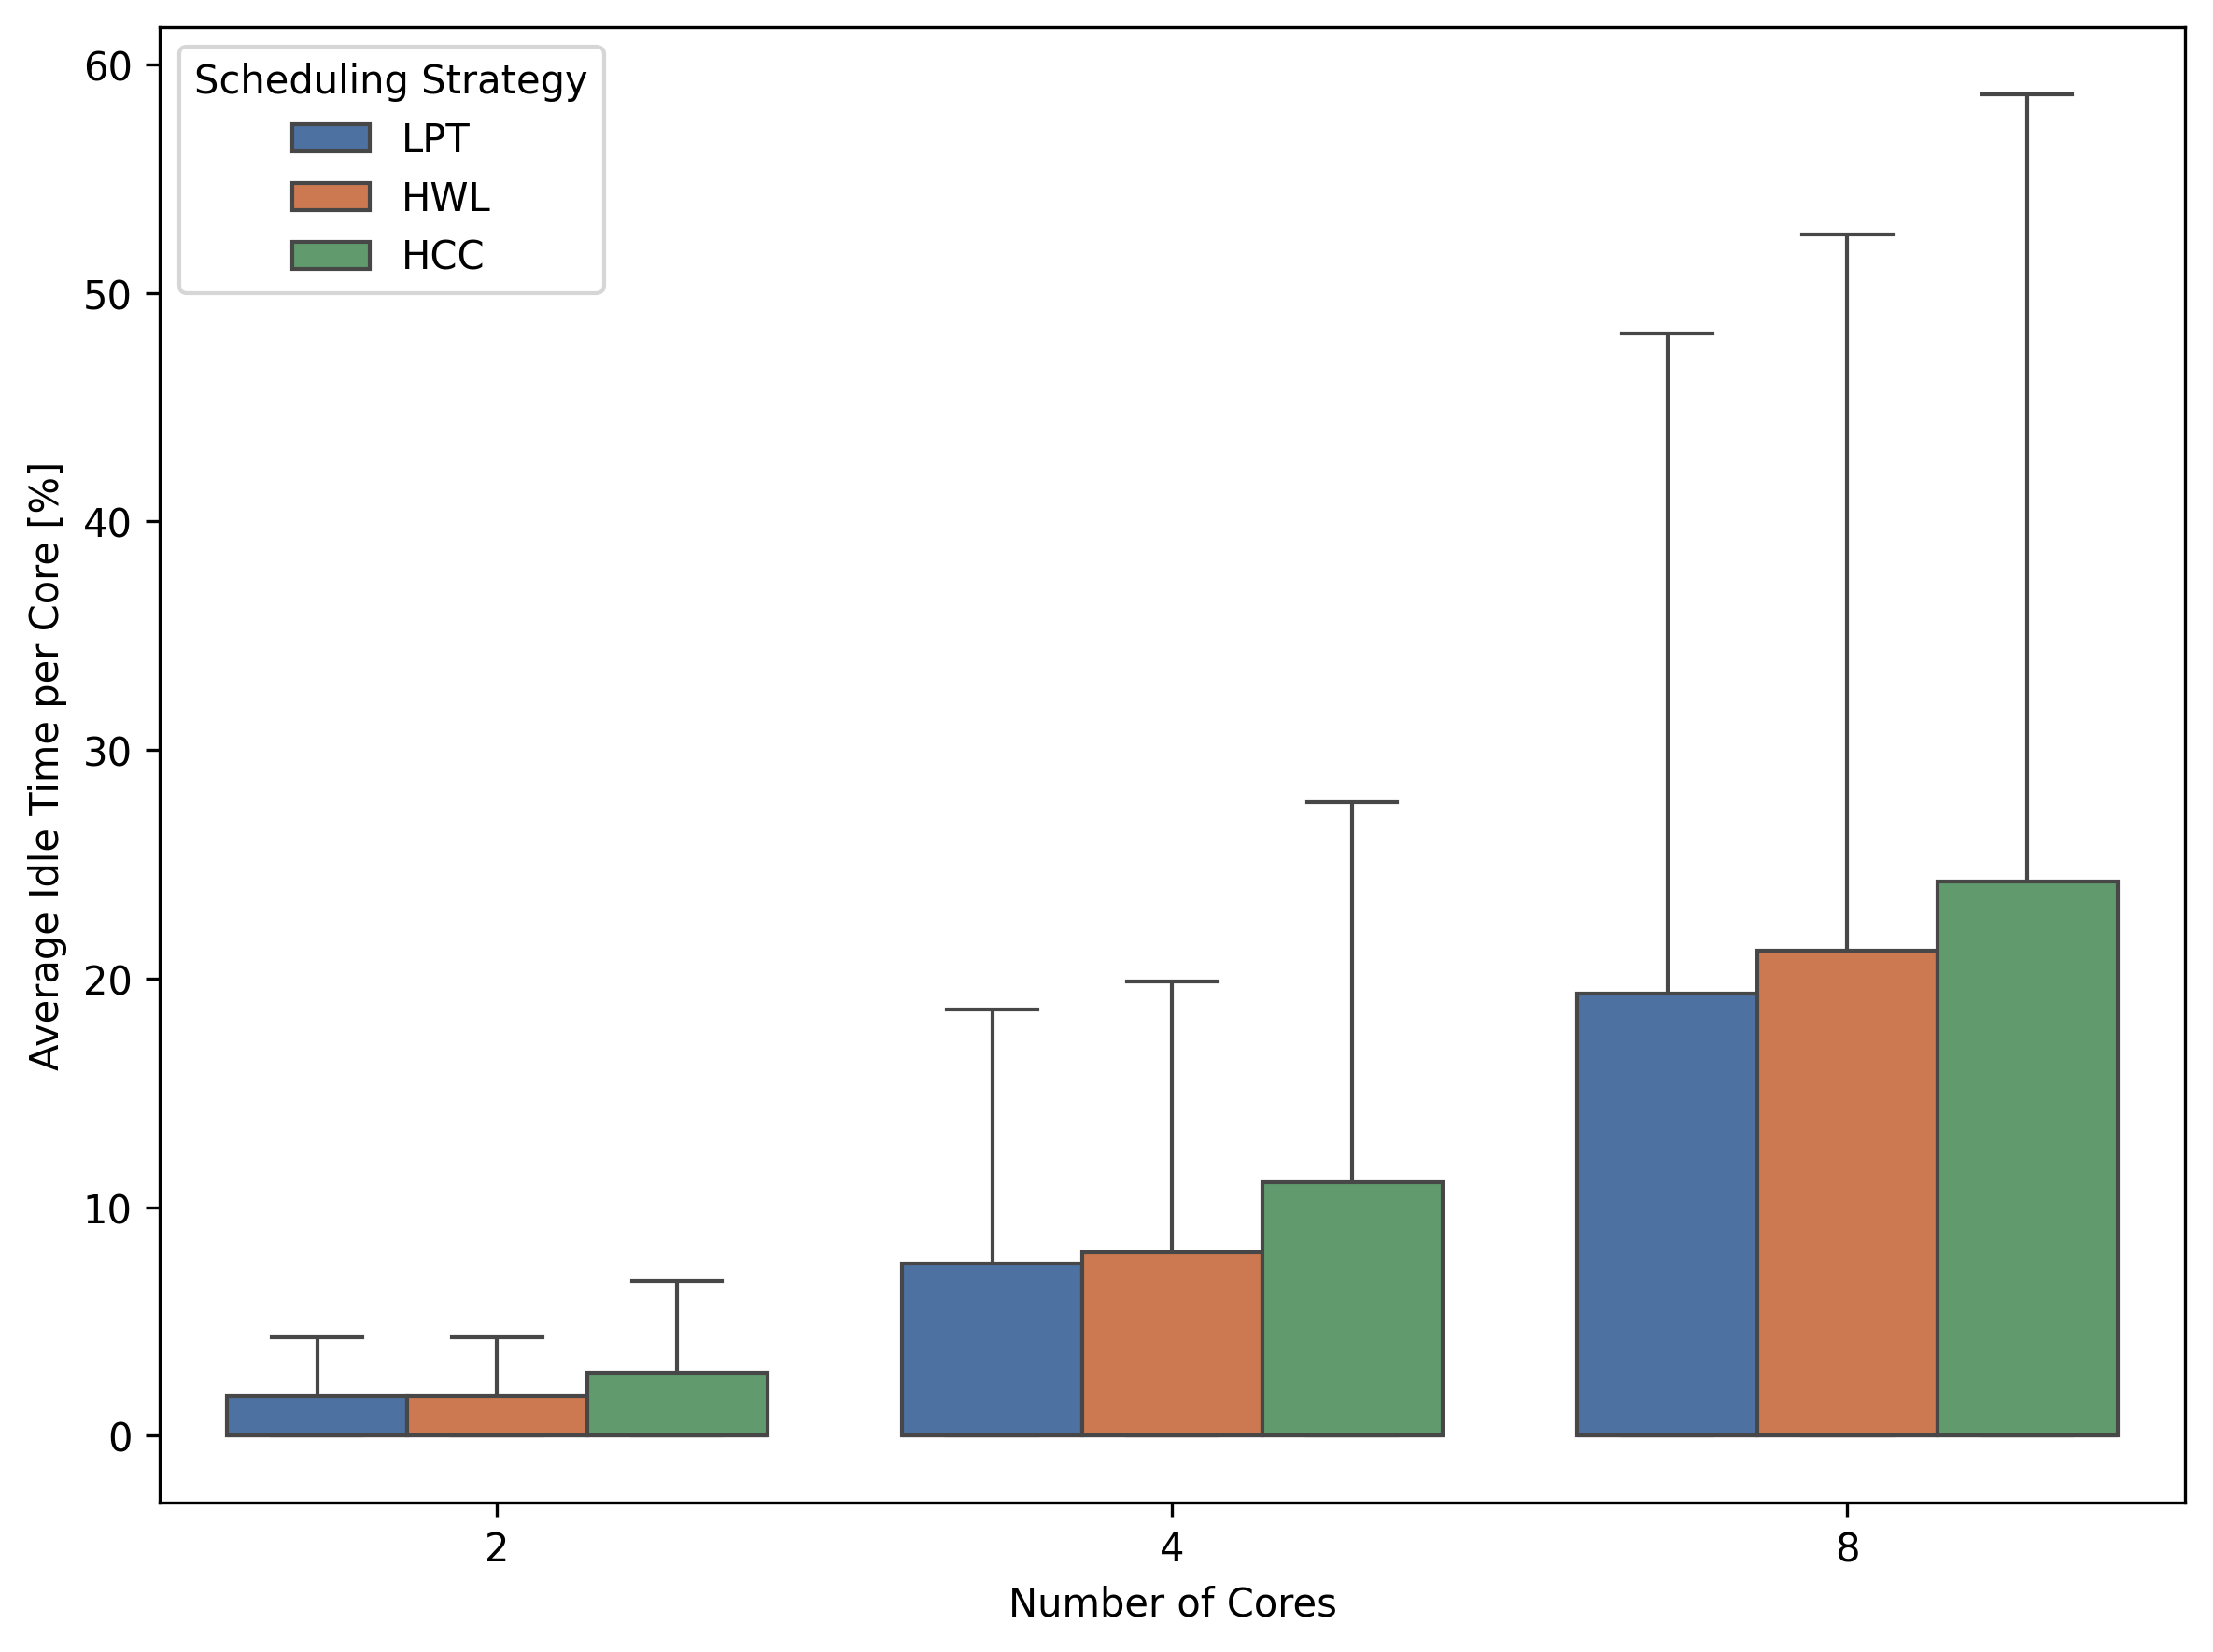

In [20]:
compare_scheduler(save_path="./figures/parallel/allot_scheduler_avg_gap.pdf")

In [21]:
# If you computed results yourself transform now
df_comp = pd.DataFrame(data_comp)
print(df_comp.columns)

Index(['task_id', 'seed', 'bmg_method', 'ensembling_method', 'allotment_method', 'n_cores', 'data_ens', 'data_bm', 'data_ens_final_ensembles'], dtype='object')


## Load Data for Figure 3 here

In [22]:
df_comp = pd.read_pickle("./analysis/result_data/df_comp.pkl")

FileNotFoundError: [Errno 2] No such file or directory: './analysis/result_data/df_comp.pkl'

In [23]:
print(df_comp.head())

   task_id  seed bmg_method ensembling_method allotment_method  n_cores                                           data_ens                                            data_bm                           data_ens_final_ensembles
0     3945     1    so-smac               ges             full        2              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...
1     3945     1    so-smac               ges            nsga2        2              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...
2     3945     1    so-smac               ges              min        2              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...              RMSE  inference_time  energy_consu...
3     3945     1    so-smac               ges             full        4              RMSE  inference

In [24]:
def compare_full_nsga2(full_group, nsga2_group):
    RES_COLS = ["inference_time", "energy_consumption"]
    res_vals_nsga2 = nsga2_group[RES_COLS].values
    assert len(full_group) == 1, "Full group should have exactly one entry"
    res_vals_full = full_group[RES_COLS].values[0]
    strictly_dominates = np.all(res_vals_nsga2 < res_vals_full, axis=1)

    if np.any(strictly_dominates):
        n_dominated = np.sum(strictly_dominates)
        inf_time_improvements = (res_vals_full[0] - res_vals_nsga2[strictly_dominates,0]) / res_vals_full[0]
        energy_improvements = (res_vals_full[1] - res_vals_nsga2[strictly_dominates,1]) / res_vals_full[1]
        return n_dominated, inf_time_improvements, energy_improvements, True
    else:        
        finds_equal = np.any([np.allclose(r, res_vals_full) for r in res_vals_nsga2])
        return 0, [], [], bool(finds_equal)

In [25]:
def plot_domination_count(bmg_method="so-smac", ensembling_method="ges", save_path=None):
    df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method)
    ]
    
    dom_counts = {n_cores : {i : 0 for i in range(0, 64)} for n_cores in [2,4,8,16,32,64]}
    
    for task_id in df_comp_filtered["task_id"].unique():
        for seed in df_comp_filtered["seed"].unique():
            for n_cores in [2,4,8,16,32,64]:
                df_subset = df_comp_filtered[
                    (df_comp_filtered["task_id"] == task_id) &
                    (df_comp_filtered["seed"] == seed) &
                    (df_comp_filtered["n_cores"] == n_cores)
                ]
                data_nsga2 = df_subset[df_subset["allotment_method"] == "nsga2"]["data_ens_final_ensembles"].iloc[0]
                data_full = df_subset[df_subset["allotment_method"] == "full"]["data_ens_final_ensembles"].iloc[0]
                data_nsga2 = data_nsga2[data_nsga2["ensemble_size"] > 1]
                data_full = data_full[data_full["ensemble_size"] > 1]
                if len(data_nsga2) == 0:
                    assert len(data_full) == 0, "NSGA-II data missing but full allotment data present"
                    continue
                
                for old_ensemble_index in data_full["old_ensemble_index"].astype(int).unique():
                    full_group = data_full[data_full["old_ensemble_index"].astype(int) == old_ensemble_index]
                    nsga2_group = data_nsga2[data_nsga2["old_ensemble_index"].astype(int) == old_ensemble_index]
                    
                    n_dominated, inf_time_imps, energy_imps, finds_equal = compare_full_nsga2(full_group, nsga2_group)
                    dom_counts[n_cores][n_dominated] += 1
                    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)
    ax.set_prop_cycle(color=COLOR_LIST)


    # x-axis is now the number of cores
    core_counts = sorted(dom_counts.keys())
    x = np.arange(len(core_counts))

    # Only plot cases where domination count > 0
    y = []

    for n_cores in core_counts:
        counts = dom_counts[n_cores]

        total_counts = sum(counts.values())
        count_gt_zero = sum(v for k, v in counts.items() if k > 0)

        y.append(count_gt_zero / total_counts)

        print(
            f"n_cores: {n_cores}, "
            f"x>0: {count_gt_zero}, "
            f"total: {total_counts}"
        )

    bar_width = 0.6
    # Different color per bar
    colors = COLOR_LIST[:len(core_counts)]

    ax.bar(
        x,
        y,
        width=bar_width,
        color=colors,
    )

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(core_counts)

    # Adjust y-axis
    ax.set_ylim(0.9, 1.0)


    ax.set_xlabel("Number of cores")
    ax.set_ylabel("Fraction of times NSGA-P dominates Max Cores")

    # Optional debug output
    for n_cores, counts in sorted(dom_counts.items()):
        total_counts = sum(counts.values())

        count_zero = counts[0]
        count_gt_zero = sum(v for k, v in counts.items() if k > 0)

        print(
            f"n_cores: {n_cores}, "
            f"x=0: {count_zero}, "
            f"x>0: {count_gt_zero}, "
            f"total: {total_counts}"
        )

    # Adjust ticks to center
    # ax.set_xticks(x + (n_groups - 1) * bar_width / 2)
    # ax.set_xticklabels(x_labels)


    # ax.set_xlabel("Does NSGA_P find a better schedule than MaxCores?")
    # ax.set_ylabel("Fraction")
    # ax.legend(title="Number of Cores")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}_{bmg_method}_{ensembling_method}.pdf", dpi=DPI, bbox_inches='tight')
    else:
        plt.show()
    return y    

In [26]:
dominated_fraction = plot_domination_count(save_path="./figures/parallel/nsga2_dominance_count")

IndexError: single positional indexer is out-of-bounds

In [27]:
RES_COLS = ["inference_time", "energy_consumption"]
metric_cols = ['Log Loss', '1 - ROC AUC', 'RMSE']
from matplotlib import patches as mpatches
from matplotlib.lines import Line2D

def plot_dom_extent(bmg_method="mo-smac", ensembling_method="mo-ges", optimization_criterion="inference_time", save_path=None,average_improvement=True,full_ensembles_only=True,plot_dominated=False,plot_outliers=False):
    df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method)
    ]
    print(f"Filtered rows: {len(df_comp_filtered)}")
    print("Available bmg_methods:", df_comp["bmg_method"].unique())
    print("Available ensembling_methods:", df_comp["ensembling_method"].unique())
    print(df_comp_filtered["seed"].unique())
    data_df = {}
    fig, ax = plt.subplots(figsize=(12, 6), dpi=DPI)
    for allotment_method_idx, allotment_method in enumerate(["nsga2", "min"]):
        improvements = np.zeros((104, 5, 6, 2, 2), dtype=float) # Shape: tasks, seeds, n_cores, inf_time/energy optimization objective, inf time/energy improvement
        improvement_counts = np.zeros((104, 5, 6), dtype=int)
        data_df[allotment_method] = []
        for i, task_id in enumerate(df_comp_filtered["task_id"].unique()):
            for j, seed in enumerate(df_comp_filtered["seed"].unique()):
                for k, n_cores in enumerate([2,4,8,16,32,64]):
                    df_subset = df_comp_filtered[
                        (df_comp_filtered["task_id"] == task_id) &
                        (df_comp_filtered["seed"] == seed) &
                        (df_comp_filtered["n_cores"] == n_cores)
                    ]
                    # df_subset = df_comp_filtered[
                    #     (df_comp_filtered["task_id"] == task_id) &
                    #     (df_comp_filtered["seed"] == seed) &
                    #     (df_comp_filtered["n_cores"] == n_cores)
                    # ].copy()
                    # df_subset["data_ens"] = df_subset["data_ens"].apply(keep_min_row)
                    if full_ensembles_only:
                        data_column = "data_ens_final_ensembles"
                    else:
                        data_column = "data_ens"
                    data_allotment = df_subset[df_subset["allotment_method"] == allotment_method][data_column].iloc[0]
                    data_full = df_subset[df_subset["allotment_method"] == "full"][data_column].iloc[0]
                    data_allotment = data_allotment[data_allotment["ensemble_size"] > 1]
                    data_full = data_full[data_full["ensemble_size"] > 1]
                    if len(data_allotment) == 0:
                        assert len(data_full) == 0, "NSGA-II data missing but full allotment data present"
                        continue
                    for old_ensemble_index in data_full["old_ensemble_index"].astype(int).unique():
                        full_group = data_full[data_full["old_ensemble_index"].astype(int) == old_ensemble_index]
                        allotment_group = data_allotment[data_allotment["old_ensemble_index"].astype(int) == old_ensemble_index]
                        
                        strictly_dominates = np.all(allotment_group[RES_COLS].values < full_group[RES_COLS].values[0], axis=1)
                        
                        improvement_counts[i, j, k] += 1
                        
                        if not average_improvement:
                            if not np.any(strictly_dominates):
                                continue
                            
                            allotment_group_dom = allotment_group[strictly_dominates]
                        else:
                            allotment_group_dom = allotment_group
                        
                        assert len(full_group) == 1, "Full group should have exactly one entry"
                        
                        for index, res in enumerate(RES_COLS):
                            min_val = allotment_group_dom[res].min()
                            min_indices = allotment_group_dom[allotment_group_dom[res] == min_val].index.tolist()
                            if len(min_indices) > 1:
                                other_res = RES_COLS[1 - index]
                                best_index = allotment_group_dom.loc[min_indices][other_res].idxmin()
                            else:
                                best_index = min_indices[0]
                            
                            improvements[i, j, k, index, :] += np.array((full_group[RES_COLS].values[0] - allotment_group_dom.loc[best_index, RES_COLS].values) / full_group[RES_COLS].values[0], dtype=float)
        if plot_dominated:
            ax2 = ax.twinx()
            ax2.plot(
            [i * 5 + 2 for i in range(6)],
            dominated_fraction,
            marker='o',
            linestyle='-',
            linewidth=2,
            markersize=7,
            color='red',
            alpha=1.0, 
        )
            line_legend = [
                Line2D(
                    [0],
                    [0],
                    color='red',
                    alpha=0.5,
                    marker='o',
                    linestyle='-',
                    linewidth=2,
                    label='Fraction of times \n NSGA-P dominates \n Max Cores'
                )
            ]
            ax2.set_ylabel("Fraction of times NSGA-P dominates Max Cores")
            
            ax2.set_ylim(-0.0, 1.1)
            legend2 = ax.legend(
                handles=line_legend,
                loc='lower right',
                fontsize=10,
                frameon=True,
            )
            
        improvements /= (improvement_counts[..., np.newaxis, np.newaxis] + 1e-12)
        for i_n_cores, n_cores in enumerate([2,4,8,16,32,64]):
            imps = improvements[:, :, i_n_cores, RES_COLS.index(optimization_criterion), :]
            imps_inf_time = imps[...,0]
            imps_energy = imps[...,1]
        
            data_df[allotment_method].append({
                "n_cores": n_cores,
                f"imps_inf_time_mean": imps_inf_time.mean(),
                f"imps_inf_time_std": imps_inf_time.std(),
                f"imps_energy_mean": imps_energy.mean(),
                f"imps_energy_std": imps_energy.std()
            })
            ax.boxplot(
                [imps_inf_time.flatten() * 100],
                positions=[i_n_cores * 5 + 0.5 +allotment_method_idx*2],
                widths=0.8,
                boxprops=dict(facecolor=COLOR_LIST[allotment_method_idx*2], color='black'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                patch_artist=True,
                showfliers=plot_outliers
            )

            ax.boxplot(
                [imps_energy.flatten() * 100],
                positions=[i_n_cores * 5 + 1.3 + allotment_method_idx*2],
                widths=0.8,
                boxprops=dict(facecolor=COLOR_LIST[allotment_method_idx*2+1], color='black'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                patch_artist=True,
                showfliers=plot_outliers
            )
        data_df[allotment_method] = pd.DataFrame(data_df[allotment_method])
    

    print(data_df["min"])
    print(data_df["nsga2"])    
    data_df = data_df["min"].merge(data_df["nsga2"], how="inner", suffixes=("_min", "_nsga2"),on="n_cores")
    
    
        
    
        
    ax.set_xticks([i * 5 + 2 for i in range(6)])
    ax.set_xticklabels([f"{n_cores} Cores" for n_cores in [2,4,8,16,32,64]])
    ax.set_xlabel("Number of Cores")
    ax.set_ylabel("Relative Cost Reduction over Full Allotment [%]")
    legend_patches = [
        mpatches.Patch(facecolor=COLOR_LIST[0], edgecolor='black', label="Inference Time: NSGA-II", hatch=''),
        mpatches.Patch(facecolor=COLOR_LIST[1], edgecolor='black', label="Energy Consumption: NSGA-II", hatch=''),
        mpatches.Patch(facecolor=COLOR_LIST[2], edgecolor='black', label="Inference Time: 1 Core per Model", hatch=''),
        mpatches.Patch(facecolor=COLOR_LIST[3], edgecolor='black', label="Energy Consumption: 1 Core per Model", hatch='')
    ]
    
    main_legend = ax.legend(handles=legend_patches, title="Cost Reduction by Metric and Allotment Method")
    ax.add_artist(main_legend)
    if plot_dominated:
        ax.add_artist(legend2)
    ax.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1,
    alpha=0.7
)
    ax.set_zorder(2)
    if plot_dominated:
        ax2.set_zorder(1)   
    else:
        ax.set_zorder(1)
#    Make primary axis background transparent
    ax.patch.set_visible(False)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}_{bmg_method}_{ensembling_method}.pdf", dpi=DPI, bbox_inches='tight')
    else:
        plt.show()
        
    # data_df = pd.DataFrame(data_df)
    print(data_df)
    for allotment_method in ["min", "nsga2"]:
        data_df[f"Inference Time Improvement [%]:{allotment_method}"] = data_df.apply(lambda row: f"{row[f'imps_inf_time_mean_{allotment_method}']*100:.2f} ({row[f'imps_inf_time_std_{allotment_method}']*100:.2f})", axis=1)
        data_df[f"Energy Consumption Improvement [%]:{allotment_method}"] = data_df.apply(lambda row: f"{row[f'imps_energy_mean_{allotment_method}']*100:.2f} ({row[f'imps_energy_std_{allotment_method}']*100:.2f})", axis=1)
    data_df.rename(columns={"n_cores": "Number of Cores"}, inplace=True)
    print(data_df[["Number of Cores", f"Inference Time Improvement [%]:min", f"Energy Consumption Improvement [%]:min",f"Inference Time Improvement [%]:nsga2",f"Energy Consumption Improvement [%]:nsga2"]].to_latex(index=False))

Filtered rows: 4086
Available bmg_methods: ['so-smac']
Available ensembling_methods: ['ges']
[1 2 3 5 4]


IndexError: single positional indexer is out-of-bounds

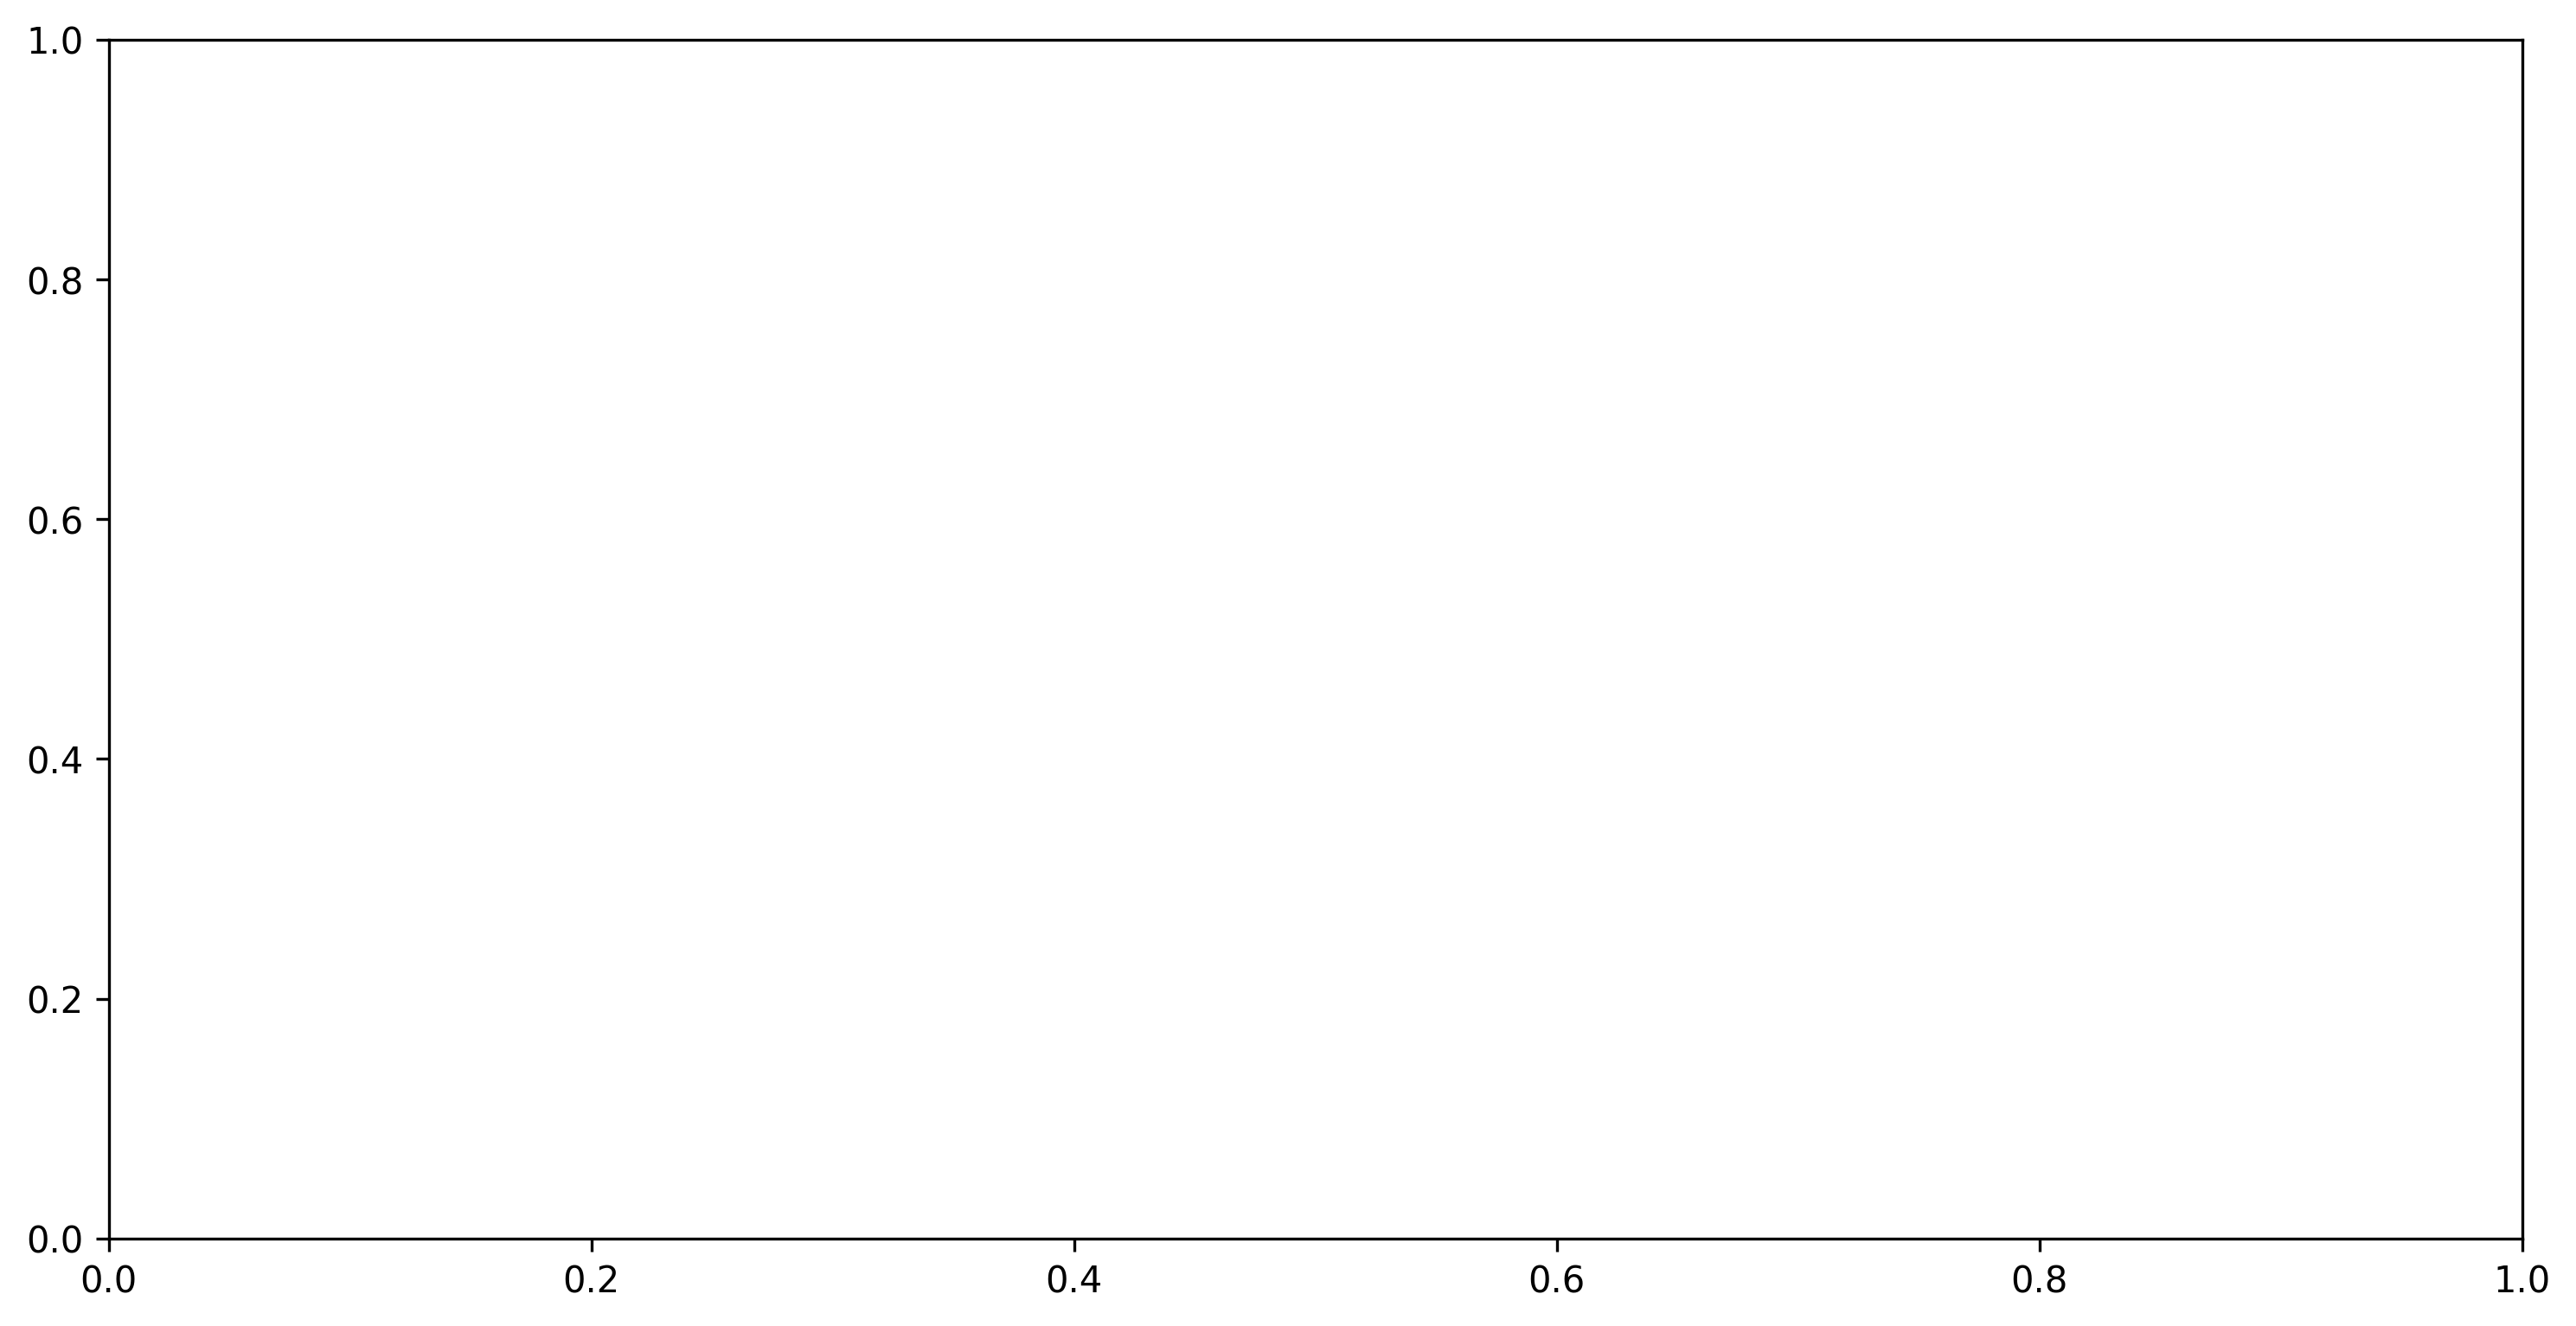

In [28]:

plot_dom_extent(bmg_method="so-smac",ensembling_method="ges",average_improvement=True,full_ensembles_only=True,optimization_criterion="inference_time",plot_dominated=False,plot_outliers=True, save_path="/home/kocher/RA-AML/analysis/notebooks/figures/parallel/dominance_extent_over_full_energy_outliers")


In [ ]:
print(np.average(dominated_fraction))
dominated_fraction

In [ ]:
#Significance extreme values inference time reduction
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd
import numpy as np

core_values = [2,4,8,16,32,64]

ALLOTMENT_METHODS = ["full", "nsga2", "min"]

records = []
df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == "so-smac") &
        (df_comp["ensembling_method"] == "ges")
    ]
for i, task_id in enumerate(df_comp_filtered["task_id"].unique()):

    for j, seed in enumerate(df_comp_filtered["seed"].unique()):

        for k, n_cores in enumerate(core_values):

            df_subset = df_comp_filtered[
                (df_comp_filtered["task_id"] == task_id) &
                (df_comp_filtered["seed"] == seed) &
                (df_comp_filtered["n_cores"] == n_cores)
            ]

            
            data_column = "data_ens_final_ensembles"
            

            method_data = {}

            for method in ALLOTMENT_METHODS:

                tmp = df_subset[
                    df_subset["allotment_method"] == method
                ][data_column].iloc[0]

                tmp = tmp[tmp["ensemble_size"] > 1]

                method_data[method] = tmp

            # -----------------------------------------------------
            # Match by old_ensemble_index
            # -----------------------------------------------------

            for old_idx in method_data["full"][
                "old_ensemble_index"
            ].astype(int).unique():

                full_group = method_data["full"][
                    method_data["full"]["old_ensemble_index"].astype(int)
                    == old_idx
                ]

                assert len(full_group) == 1

                full_vals = full_group[RES_COLS].values[0]

                row = {
                    "task_id": task_id,
                    "seed": seed,
                    "n_cores": n_cores,
                    "old_ensemble_index": old_idx,
                }

                # baseline
                for r_idx, res in enumerate(RES_COLS):
                    row[f"full_{res}"] = full_vals[r_idx]

                # -------------------------------------------------
                # Representative value for each allotment method
                # -------------------------------------------------

                for method in ["nsga2", "min"]:

                    group = method_data[method][
                        method_data[method]["old_ensemble_index"].astype(int)
                        == old_idx
                    ]

                    if len(group) == 0:
                        continue

                    min_val = group["inference_time"].min()
                    min_indices = group[
                            group["inference_time"] == min_val
                        ].index.tolist()
                    if len(min_indices) > 1:
                            best_index = group.loc[min_indices][
                                "energy_consumption"
                            ].idxmin()
                    else:
                        best_index = min_indices[0]
                    selected = group.loc[best_index]
                    for metric in RES_COLS:
                        row[f"{method}_{metric}"] = selected[metric]

                records.append(row)

raw_df = pd.DataFrame(records)
friedman_results = []

for n_cores in core_values:

    df_core = raw_df[raw_df["n_cores"] == n_cores]

    for metric in RES_COLS:

        cols = [
            f"full_{metric}",
            f"nsga2_{metric}",
            f"min_{metric}",
        ]

        # df_test = df_core[cols].dropna()

        if len(df_core) < 2:
            continue

        stat, p = friedmanchisquare(
            df_core[cols[0]],
            df_core[cols[1]],
            df_core[cols[2]],
        )

        friedman_results.append({
            "n_cores": n_cores,
            "metric": metric,
            "friedman_statistic": stat,
            "p_value": p,
            "n_samples": len(df_core),
        })

friedman_df = pd.DataFrame(friedman_results)

print(friedman_df)
posthoc_results = []

for n_cores in core_values:

    df_core = raw_df[raw_df["n_cores"] == n_cores]

    for metric in RES_COLS:

        pairs = [
            ("nsga2","full"),
            ("min","full"),
            ("nsga2", "min"),
            ("min", "nsga2"),

        ]

        for a, b in pairs:

            cols = [f"{a}_{metric}", f"{b}_{metric}"]

                        # BEFORE dropna()
            # n_before = len(df_core[cols])
            # n_missing_a = df_core[cols[0]].isna().sum()
            # n_missing_b = df_core[cols[1]].isna().sum()
            
            # # df_test = df_core[cols].dropna()
            
            # # AFTER dropna()
            # n_after = len(df_core)
            # n_dropped = n_before - n_after
            # print(n_dropped)

            if len(df_core) < 2:
                continue

            stat, p = wilcoxon(
                df_core[cols[0]],
                df_core[cols[1]],
                alternative="less"
            )

            posthoc_results.append({
                "n_cores": n_cores,
                "metric": metric,
                "comparison": f"{a} < {b}",
                "p_value": p,
                # "n_samples": len(df_core),
            })
pd.set_option('display.float_format', '{:.6f}'.format)
posthoc_df = pd.DataFrame(posthoc_results)
print(posthoc_df)

In [ ]:
#Significance extreme values energy consumption reduction
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd
import numpy as np

core_values = [2,4,8,16,32,64]

ALLOTMENT_METHODS = ["full", "nsga2", "min"]

records = []
df_comp_filtered = df_comp[
        (df_comp["bmg_method"] == "so-smac") &
        (df_comp["ensembling_method"] == "ges")
    ]
for i, task_id in enumerate(df_comp_filtered["task_id"].unique()):

    for j, seed in enumerate(df_comp_filtered["seed"].unique()):

        for k, n_cores in enumerate(core_values):

            df_subset = df_comp_filtered[
                (df_comp_filtered["task_id"] == task_id) &
                (df_comp_filtered["seed"] == seed) &
                (df_comp_filtered["n_cores"] == n_cores)
            ]

            
            data_column = "data_ens_final_ensembles"
            

            method_data = {}

            for method in ALLOTMENT_METHODS:

                tmp = df_subset[
                    df_subset["allotment_method"] == method
                ][data_column].iloc[0]

                tmp = tmp[tmp["ensemble_size"] > 1]

                method_data[method] = tmp

            # -----------------------------------------------------
            # Match by old_ensemble_index
            # -----------------------------------------------------

            for old_idx in method_data["full"][
                "old_ensemble_index"
            ].astype(int).unique():

                full_group = method_data["full"][
                    method_data["full"]["old_ensemble_index"].astype(int)
                    == old_idx
                ]

                assert len(full_group) == 1

                full_vals = full_group[RES_COLS].values[0]

                row = {
                    "task_id": task_id,
                    "seed": seed,
                    "n_cores": n_cores,
                    "old_ensemble_index": old_idx,
                }

                # baseline
                for r_idx, res in enumerate(RES_COLS):
                    row[f"full_{res}"] = full_vals[r_idx]

                # -------------------------------------------------
                # Representative value for each allotment method
                # -------------------------------------------------

                for method in ["nsga2", "min"]:

                    group = method_data[method][
                        method_data[method]["old_ensemble_index"].astype(int)
                        == old_idx
                    ]

                    if len(group) == 0:
                        continue

                    min_val = group["energy_consumption"].min()
                    min_indices = group[
                            group["energy_consumption"] == min_val
                        ].index.tolist()
                    if len(min_indices) > 1:
                            best_index = group.loc[min_indices][
                                "inference_time"
                            ].idxmin()
                    else:
                        best_index = min_indices[0]
                    selected = group.loc[best_index]
                    for metric in RES_COLS:
                        row[f"{method}_{metric}"] = selected[metric]

                records.append(row)

raw_df = pd.DataFrame(records)
friedman_results = []

for n_cores in core_values:

    df_core = raw_df[raw_df["n_cores"] == n_cores]

    for metric in RES_COLS:

        cols = [
            f"full_{metric}",
            f"nsga2_{metric}",
            f"min_{metric}",
        ]

        # df_test = df_core[cols].dropna()

        if len(df_core) < 2:
            continue

        stat, p = friedmanchisquare(
            df_core[cols[0]],
            df_core[cols[1]],
            df_core[cols[2]],
        )

        friedman_results.append({
            "n_cores": n_cores,
            "metric": metric,
            "friedman_statistic": stat,
            "p_value": p,
            "n_samples": len(df_core),
        })

friedman_df = pd.DataFrame(friedman_results)

print(friedman_df)
posthoc_results = []

for n_cores in core_values:

    df_core = raw_df[raw_df["n_cores"] == n_cores]

    for metric in RES_COLS:

        pairs = [
            ("nsga2","full"),
            ("min","full"),
            ("nsga2", "min"),
            ("min", "nsga2"),

        ]

        for a, b in pairs:

            cols = [f"{a}_{metric}", f"{b}_{metric}"]

                        # BEFORE dropna()
            # n_before = len(df_core[cols])
            # n_missing_a = df_core[cols[0]].isna().sum()
            # n_missing_b = df_core[cols[1]].isna().sum()
            
            # # df_test = df_core[cols].dropna()
            
            # # AFTER dropna()
            # n_after = len(df_core)
            # n_dropped = n_before - n_after
            # print(n_dropped)

            if len(df_core) < 2:
                continue

            stat, p = wilcoxon(
                df_core[cols[0]],
                df_core[cols[1]],
                alternative="less"
            )

            posthoc_results.append({
                "n_cores": n_cores,
                "metric": metric,
                "comparison": f"{a} < {b}",
                "p_value": p,
                # "n_samples": len(df_core),
            })
pd.set_option('display.float_format', '{:.6f}'.format)
posthoc_df = pd.DataFrame(posthoc_results)
print(posthoc_df)

# Heterogeneity Analysis

Tests whether NSGA-P's advantage over Min-Cores (1 core per model) grows with how
heterogeneous an ensemble's members are in cost. Uses `inference_times` (per-member,
weight > 0, single-core-profiled inference times) added to `base_ensemble_pools.csv` by
`extract_ensemble_inference_times` / `collect_ensembling_inference_times.py` /
`collect_ensembling_results.py`. No new runs needed -- this is pure post-hoc analysis of
`data_ens` (already loaded above) and `df_comp` (already loaded/computed above).

Requires `data_ens` to have an `inference_times` column (list of floats per ensemble). If it
doesn't, re-run the collection pipeline: `collect_ensembling_predictions.py` ->
`collect_ensembling_inference_times.py` -> `collect_ensembling_results.py`, then reload
`data_ens` in the "Ensembling" section above.

In [29]:
import json
assert "inference_times" in data_ens.columns, (
    "data_ens has no inference_times column -- re-run collect_ensembling_predictions.py -> "
    "collect_ensembling_inference_times.py -> collect_ensembling_results.py, then reload data_ens "
    "in the cell above before running this section."
)

# inference_times survives one CSV round trip as a JSON-ish string ("[0.12, 0.34, ...]");
# parse it back into a list once, up front.
if data_ens["inference_times"].dtype == object and isinstance(data_ens["inference_times"].iloc[0], str):
    data_ens["inference_times"] = data_ens["inference_times"].apply(json.loads)


In [34]:
def compute_heterogeneity_index(inference_times, mode="cv"):
    """H = max/min ("ratio") or coefficient of variation ("cv") of an ensemble's per-member
    (weight > 0) single-core inference times. Undefined (NaN) for ensembles with < 2 members
    or non-positive times."""
    times = np.asarray(inference_times, dtype=float)
    if len(times) < 2:
        return np.nan
    if mode == "ratio":
        if times.min() <= 0:
            return np.nan
        return times.max() / times.min()
    elif mode == "cv":
        mean = times.mean()
        if mean <= 0:
            return np.nan
        return times.std() / mean
    else:
        raise ValueError(f"Unknown mode: {mode}")


data_ens["heterogeneity_index"] = data_ens["inference_times"].apply(compute_heterogeneity_index)

# old_ensemble_index (as referenced in data_parallel / df_comp) is the ensemble's 0-based
# position within its (task_id, seed, bmg_method, es_method) group, in original CSV row order --
# same convention process_job (above) relies on via np.where(pareto_mask)[0]. groupby.cumcount()
# preserves original row order per group, so this lines up as long as data_ens has not been
# re-sorted since it was loaded/filtered above.
data_ens["old_ensemble_index"] = data_ens.groupby(["task_id", "seed", "bmg_method", "es_method"]).cumcount()

heterogeneity_lookup = data_ens.set_index(
    ["task_id", "seed", "bmg_method", "es_method", "old_ensemble_index"]
)["heterogeneity_index"]

print(data_ens["heterogeneity_index"].describe())


count    8492.000000
mean        0.411878
std         0.363933
min         0.000510
25%         0.119924
50%         0.328079
75%         0.617844
max         2.355958
Name: heterogeneity_index, dtype: float64


In [35]:
def compute_nsga_vs_min_gap_per_ensemble(df_comp, heterogeneity_lookup, bmg_method="so-smac",
                                          ensembling_method="ges", full_ensembles_only=True):
    """
    Per (task_id, seed, n_cores, old_ensemble_index): relative inference-time improvement over
    Full Allotment achieved by NSGA-P and by Min-Cores (best dominating point, same selection
    rule as plot_dom_extent above), then gap = nsga2_improvement - min_improvement.
    Positive gap => NSGA-P reduces inference time more than simply giving every model 1 core.
    """
    RES_COL = "inference_time"
    data_column = "data_ens_final_ensembles" if full_ensembles_only else "data_ens"

    df_filtered = df_comp[
        (df_comp["bmg_method"] == bmg_method) &
        (df_comp["ensembling_method"] == ensembling_method)
    ]

    records = []
    for (task_id, seed, n_cores), df_subset in df_filtered.groupby(["task_id", "seed", "n_cores"]):
        full_rows = df_subset[df_subset["allotment_method"] == "full"][data_column]
        nsga2_rows = df_subset[df_subset["allotment_method"] == "nsga2"][data_column]
        min_rows = df_subset[df_subset["allotment_method"] == "min"][data_column]
        if full_rows.empty or nsga2_rows.empty or min_rows.empty:
            continue

        data_full = full_rows.iloc[0]
        data_nsga2 = nsga2_rows.iloc[0]
        data_min = min_rows.iloc[0]

        data_full = data_full[data_full["ensemble_size"] > 1]
        data_nsga2 = data_nsga2[data_nsga2["ensemble_size"] > 1]
        data_min = data_min[data_min["ensemble_size"] > 1]
        if len(data_full) == 0:
            continue

        for old_ensemble_index in data_full["old_ensemble_index"].astype(int).unique():
            full_group = data_full[data_full["old_ensemble_index"].astype(int) == old_ensemble_index]
            nsga2_group = data_nsga2[data_nsga2["old_ensemble_index"].astype(int) == old_ensemble_index]
            min_group = data_min[data_min["old_ensemble_index"].astype(int) == old_ensemble_index]
            if len(full_group) != 1 or len(nsga2_group) == 0 or len(min_group) == 0:
                continue

            full_time = full_group[RES_COL].values[0]
            if full_time <= 0:
                continue
            nsga2_time = nsga2_group[RES_COL].min()
            min_time = min_group[RES_COL].min()

            nsga2_improvement = (full_time - nsga2_time) / full_time
            min_improvement = (full_time - min_time) / full_time

            het = heterogeneity_lookup.get((task_id, seed, bmg_method, ensembling_method, old_ensemble_index), np.nan)

            records.append({
                "task_id": task_id,
                "seed": seed,
                "n_cores": n_cores,
                "old_ensemble_index": old_ensemble_index,
                "heterogeneity_index": het,
                "nsga2_improvement": nsga2_improvement,
                "min_improvement": min_improvement,
                "gap": nsga2_improvement - min_improvement,
            })

    return pd.DataFrame(records)


gap_df = compute_nsga_vs_min_gap_per_ensemble(df_comp, heterogeneity_lookup, bmg_method="so-smac", ensembling_method="ges")
print(f"{len(gap_df)} ensemble/core-budget rows, {gap_df['heterogeneity_index'].notna().sum()} with a defined heterogeneity index")
gap_df.head()


1350 ensemble/core-budget rows, 1350 with a defined heterogeneity index


,task_id,seed,n_cores,old_ensemble_index,heterogeneity_index,nsga2_improvement,min_improvement,gap
0,3945,1,2,42,1.862294,0.094115,0.094115,0.000000
1,3945,1,4,42,1.862294,0.407256,-0.049949,0.457204
2,3945,1,8,42,1.862294,0.020041,-0.829883,0.849924
3,3945,1,16,42,1.862294,-0.489846,-1.781999,1.292153
4,3945,1,32,42,1.862294,-0.717152,-2.206448,1.489296


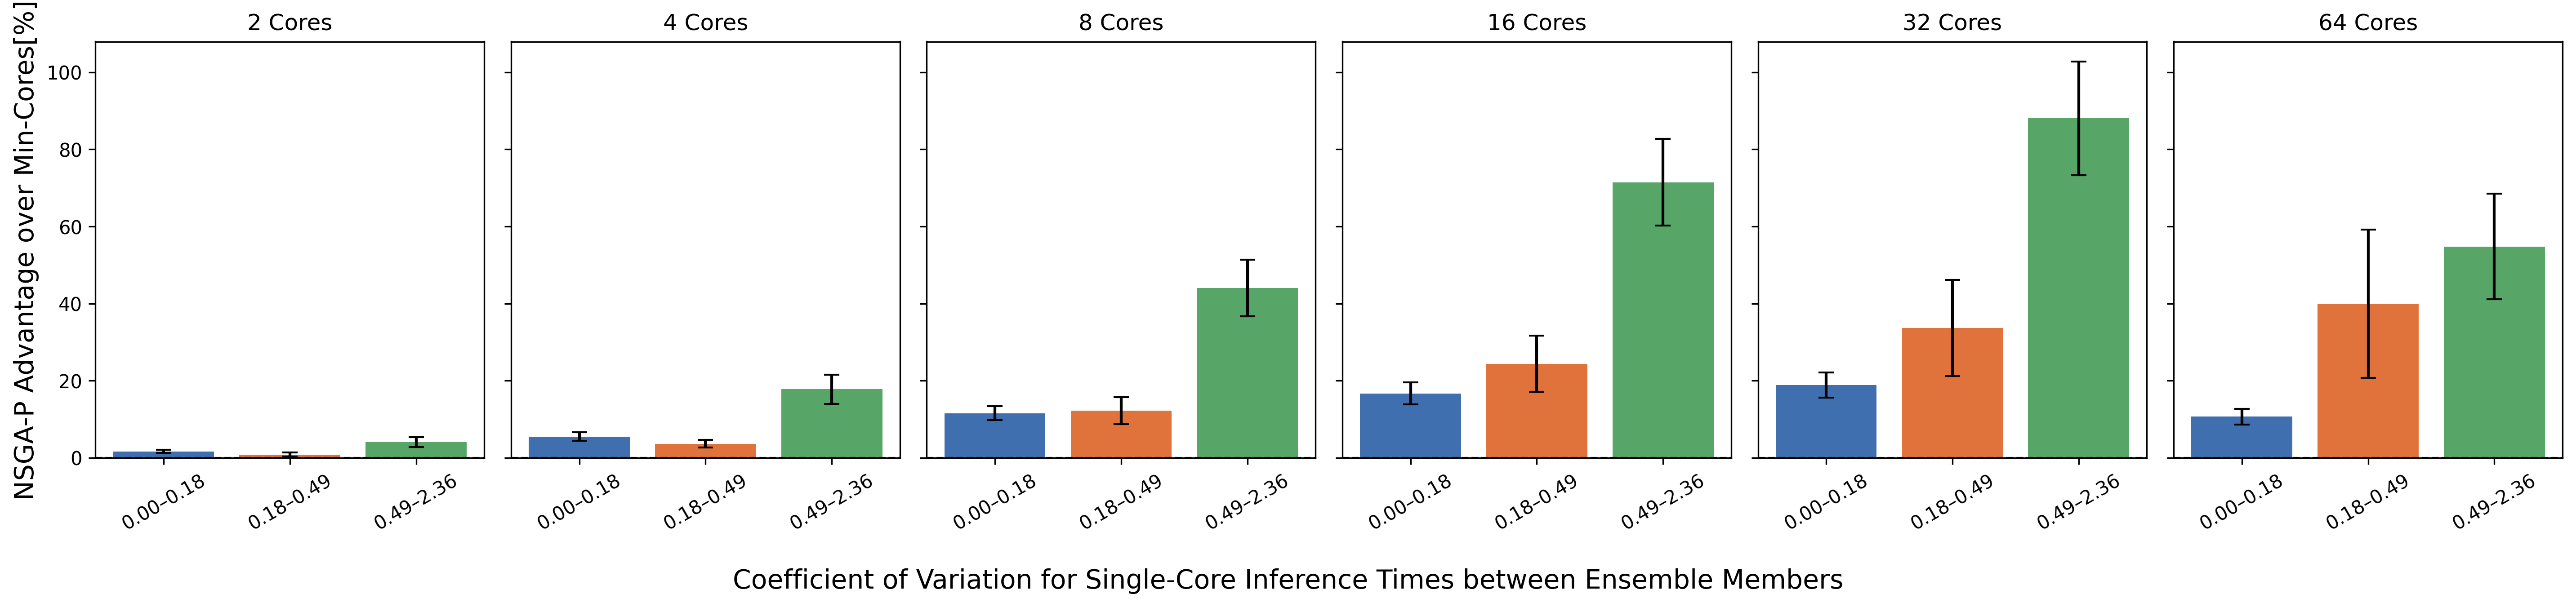

In [55]:
def plot_heterogeneity_gap_by_tertile(gap_df, n_cores_list=(2, 4, 8, 16, 32, 64), save_path=None):
    """Bar plot: mean NSGA-P advantage over Min-Cores (inference-time reduction gap), binned into
    tertiles of heterogeneity index H, one panel per core budget. Bar labels show the actual H
    cutting points for that panel's tertiles rather than "Low/Mid/High"."""
    fig, axes = plt.subplots(1, len(n_cores_list), figsize=(3.2 * len(n_cores_list), 4.5), sharey=True, dpi=DPI)

    for ax, n_cores in zip(axes, n_cores_list):
        sub = gap_df[gap_df["n_cores"] == n_cores].dropna(subset=["heterogeneity_index", "gap"])
        if len(sub) < 3:
            ax.set_title(f"{n_cores} Cores\n(n={len(sub)})")
            continue
        sub = sub.copy()
        try:
            sub["H_tertile"], bin_edges = pd.qcut(sub["heterogeneity_index"], 3, retbins=True, duplicates="drop")
        except ValueError:
            ax.set_title(f"{n_cores} Cores\n(not enough distinct H)",fontsize=10)
            continue

        labels = [f"{bin_edges[i]:.2f}\u2013{bin_edges[i + 1]:.2f}" for i in range(len(bin_edges) - 1)]
        sub["H_tertile"] = sub["H_tertile"].cat.rename_categories(labels)

        means = sub.groupby("H_tertile", observed=True)["gap"].mean() * 100
        sems = sub.groupby("H_tertile", observed=True)["gap"].sem() * 100

        ax.bar(means.index.astype(str), means.values, yerr=sems.values,
               color=COLOR_LIST[:len(means)], capsize=4)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{n_cores} Cores")
        
        ax.tick_params(axis="x", rotation=30)
    fig.supxlabel("Coefficient of Variation for Single-Core Inference Times between Ensemble Members",fontsize=14)
    axes[0].set_ylabel("NSGA-P Advantage over Min-Cores[%]",fontsize=14)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    else:
        plt.show()


plot_heterogeneity_gap_by_tertile(gap_df, save_path="/home/kocher/RA-AML/analysis/notebooks/figures/parallel/heterogeneity_gap_tertiles.pdf")


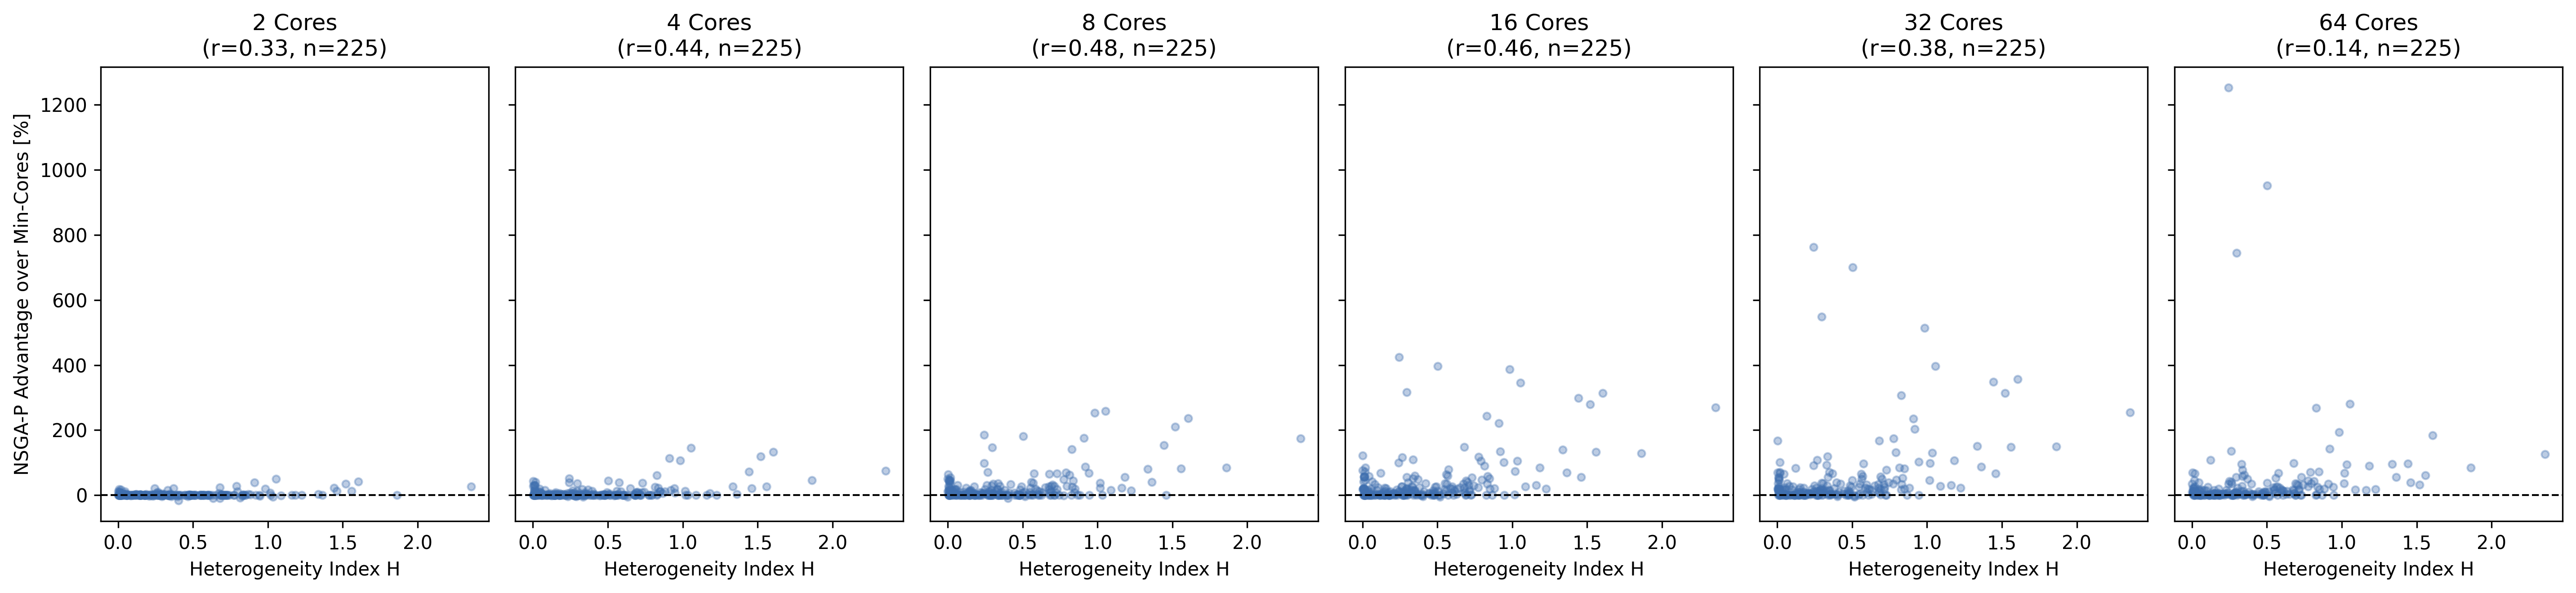

In [38]:
def plot_heterogeneity_scatter(gap_df, n_cores_list=(2, 4, 8, 16, 32, 64), save_path=None):
    """Scatter: heterogeneity index H vs. NSGA-P advantage over Min-Cores, one panel per core
    budget -- same multi-panel layout as plot_heterogeneity_gap_by_tertile above."""
    fig, axes = plt.subplots(1, len(n_cores_list), figsize=(3.2 * len(n_cores_list), 4.5), sharey=True, dpi=DPI)
    if len(n_cores_list) == 1:
        axes = [axes]

    for ax, n_cores in zip(axes, n_cores_list):
        sub = gap_df[gap_df["n_cores"] == n_cores].dropna(subset=["heterogeneity_index", "gap"])

        ax.scatter(sub["heterogeneity_index"], sub["gap"] * 100, alpha=0.35, s=15, color=COLOR_LIST[0])
        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        if len(sub) > 2:
            corr = sub["heterogeneity_index"].corr(sub["gap"])
            ax.set_title(f"{n_cores} Cores\n(r={corr:.2f}, n={len(sub)})")
        else:
            ax.set_title(f"{n_cores} Cores\n(n={len(sub)})")

        ax.set_xlabel("Coefficient of Variation for Single-Core Inference Times")

    axes[0].set_ylabel("NSGA-P Advantage over Min-Cores [%]")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    else:
        plt.show()


plot_heterogeneity_scatter(gap_df, save_path="./figures/parallel/heterogeneity_scatter.pdf")
